# Multi-Layer Neural Network from Scratch (Pure Python + NumPy)

A fully modular, from-scratch feed-forward neural network implementation.

**Features**
- Any depth, any width — add as many layers with as many neurons as you like
- Common activation functions: `sigmoid`, `relu`, `leaky_relu`, `tanh`, `linear`, `softmax`
- Common loss functions: `mse`, `mae`, `binary_crossentropy`, `categorical_crossentropy`
- Mini-batch gradient descent with `sgd` or `adam` optimizer
- Numerically-stable gradients for the `softmax + categorical_crossentropy` and `sigmoid + binary_crossentropy` combos
- Tested on a real Kaggle dataset: **Pima Indians Diabetes Database** (binary classification)
- Train vs. test loss curves plotted at the end

No TensorFlow, no PyTorch — just `numpy`.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
%matplotlib inline

## 2. Activation Functions

Each activation is stored as a `(function, derivative)` pair, keyed by name in the `ACTIVATIONS` dictionary. Adding a new activation later is just a matter of adding one more entry to this dictionary — nothing else in the library needs to change.

In [2]:
def _sigmoid(z):
    z = np.clip(z, -500, 500)          # avoid overflow in exp
    return 1.0 / (1.0 + np.exp(-z))

def _sigmoid_deriv(z):
    s = _sigmoid(z)
    return s * (1 - s)

def _relu(z):
    return np.maximum(0, z)

def _relu_deriv(z):
    return (z > 0).astype(z.dtype)

def _leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def _leaky_relu_deriv(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha)

def _tanh(z):
    return np.tanh(z)

def _tanh_deriv(z):
    return 1 - np.tanh(z) ** 2

def _linear(z):
    return z

def _linear_deriv(z):
    return np.ones_like(z)

def _softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)   # numerical stability
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)

def _softmax_deriv(z):
    # Softmax is always paired with categorical cross-entropy in this
    # library. The combined gradient of that pair simplifies neatly to
    # (y_pred - y_true), so this placeholder derivative is never
    # actually used in the backward pass (see the output-layer
    # shortcut in NeuralNetwork.backward below).
    return np.ones_like(z)

ACTIVATIONS = {
    'sigmoid':    (_sigmoid, _sigmoid_deriv),
    'relu':       (_relu, _relu_deriv),
    'leaky_relu': (_leaky_relu, _leaky_relu_deriv),
    'tanh':       (_tanh, _tanh_deriv),
    'linear':     (_linear, _linear_deriv),
    'softmax':    (_softmax, _softmax_deriv),
}

## 3. Loss Functions

Same pattern: `(loss, derivative_wrt_prediction)` pairs in a `LOSSES` dictionary.

In [3]:
def _mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def _mse_deriv(y_true, y_pred):
    return (2.0 / y_true.shape[0]) * (y_pred - y_true)

def _mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def _mae_deriv(y_true, y_pred):
    return np.sign(y_pred - y_true) / y_true.shape[0]

def _binary_crossentropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def _binary_crossentropy_deriv(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return (-(y_true / y_pred) + (1 - y_true) / (1 - y_pred)) / y_true.shape[0]

def _categorical_crossentropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

def _categorical_crossentropy_deriv(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return (-(y_true / y_pred)) / y_true.shape[0]

LOSSES = {
    'mse':                      (_mse, _mse_deriv),
    'mae':                      (_mae, _mae_deriv),
    'binary_crossentropy':      (_binary_crossentropy, _binary_crossentropy_deriv),
    'categorical_crossentropy': (_categorical_crossentropy, _categorical_crossentropy_deriv),
}

# (output_activation, loss) pairs whose combined gradient simplifies
# algebraically to (y_pred - y_true). Using this shortcut avoids the
# numerically messy full Jacobian of softmax / division-heavy
# cross-entropy derivatives.
_STABLE_OUTPUT_PAIRS = {
    ('softmax', 'categorical_crossentropy'),
    ('sigmoid', 'binary_crossentropy'),
}

## 4. The `Dense` Layer

A single fully-connected layer. Handles its own forward pass, backward pass, and parameter update (`sgd` or `adam`). Weight initialization automatically switches between He (good for ReLU family) and Xavier (good for sigmoid/tanh/linear/softmax) unless you override it.

In [4]:
class Dense:
    """A single fully-connected layer: Z = A_prev.W + b ; A = activation(Z)"""

    def __init__(self, n_inputs, n_neurons, activation='relu', weight_init='auto'):
        if activation not in ACTIVATIONS:
            raise ValueError(f"Unknown activation '{activation}'. Choices: {list(ACTIVATIONS)}")
        self.activation_name = activation
        self.act_fn, self.act_deriv_fn = ACTIVATIONS[activation]

        if weight_init == 'auto':
            weight_init = 'he' if activation in ('relu', 'leaky_relu') else 'xavier'

        if weight_init == 'he':
            scale = np.sqrt(2.0 / n_inputs)
        elif weight_init == 'xavier':
            scale = np.sqrt(1.0 / n_inputs)
        else:
            scale = 0.01

        self.W = np.random.randn(n_inputs, n_neurons) * scale
        self.b = np.zeros((1, n_neurons))

        # Adam optimizer moment buffers (only used if optimizer='adam')
        self.mW = np.zeros_like(self.W); self.vW = np.zeros_like(self.W)
        self.mb = np.zeros_like(self.b); self.vb = np.zeros_like(self.b)

        self.A_prev = None
        self.Z = None
        self.dW = None
        self.db = None

    def forward(self, A_prev):
        self.A_prev = A_prev
        self.Z = A_prev @ self.W + self.b
        return self.act_fn(self.Z)

    def backward(self, dA, output_shortcut=False):
        """
        dA: gradient of loss wrt this layer's output activation A.
        output_shortcut: if True, dA is already dL/dZ (used for the
                          numerically-stable softmax+CE / sigmoid+BCE pairing).
        """
        dZ = dA if output_shortcut else dA * self.act_deriv_fn(self.Z)

        m = self.A_prev.shape[0]
        self.dW = self.A_prev.T @ dZ / m
        self.db = np.sum(dZ, axis=0, keepdims=True) / m
        dA_prev = dZ @ self.W.T
        return dA_prev

    def step(self, lr, optimizer='sgd', t=1, beta1=0.9, beta2=0.999, eps=1e-8):
        if optimizer == 'sgd':
            self.W -= lr * self.dW
            self.b -= lr * self.db
        elif optimizer == 'adam':
            self.mW = beta1 * self.mW + (1 - beta1) * self.dW
            self.vW = beta2 * self.vW + (1 - beta2) * (self.dW ** 2)
            self.mb = beta1 * self.mb + (1 - beta1) * self.db
            self.vb = beta2 * self.vb + (1 - beta2) * (self.db ** 2)

            mW_hat = self.mW / (1 - beta1 ** t); vW_hat = self.vW / (1 - beta2 ** t)
            mb_hat = self.mb / (1 - beta1 ** t); vb_hat = self.vb / (1 - beta2 ** t)

            self.W -= lr * mW_hat / (np.sqrt(vW_hat) + eps)
            self.b -= lr * mb_hat / (np.sqrt(vb_hat) + eps)
        else:
            raise ValueError(f"Unknown optimizer '{optimizer}'")

## 5. The `NeuralNetwork` Class

This is the modular part: call `.add()` as many times as you like, with any width and any activation, to build a network of arbitrary depth. Then `.compile()` with a loss + optimizer, and `.fit()`.

In [5]:
class NeuralNetwork:
    """
    Modular fully-connected neural network of arbitrary depth/width.

    Example
    -------
    nn = NeuralNetwork(input_dim=8)
    nn.add(16, activation='relu')
    nn.add(8,  activation='relu')
    nn.add(1,  activation='sigmoid')
    nn.compile(loss='binary_crossentropy', optimizer='adam', learning_rate=0.01)
    history = nn.fit(X_train, y_train, X_val=X_test, y_val=y_test,
                      epochs=200, batch_size=32)
    """

    def __init__(self, input_dim):
        self.input_dim = input_dim
        self.layers = []
        self.loss_name = None
        self.loss_fn = None
        self.loss_deriv_fn = None
        self.optimizer = 'sgd'
        self.learning_rate = 0.01
        self._t = 0  # adam timestep

    def add(self, n_neurons, activation='relu', weight_init='auto'):
        n_inputs = self.input_dim if not self.layers else self.layers[-1].W.shape[1]
        self.layers.append(Dense(n_inputs, n_neurons, activation, weight_init))
        return self

    def compile(self, loss='mse', optimizer='sgd', learning_rate=0.01):
        if loss not in LOSSES:
            raise ValueError(f"Unknown loss '{loss}'. Choices: {list(LOSSES)}")
        self.loss_name = loss
        self.loss_fn, self.loss_deriv_fn = LOSSES[loss]
        self.optimizer = optimizer
        self.learning_rate = learning_rate

    def forward(self, X):
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A

    def backward(self, y_true, y_pred):
        last = self.layers[-1]
        pair = (last.activation_name, self.loss_name)

        if pair in _STABLE_OUTPUT_PAIRS:
            dZ = (y_pred - y_true) / y_true.shape[0]
            dA = last.backward(dZ, output_shortcut=True)
        else:
            dA = self.loss_deriv_fn(y_true, y_pred)
            dA = last.backward(dA)

        for layer in reversed(self.layers[:-1]):
            dA = layer.backward(dA)

    def update(self):
        self._t += 1
        for layer in self.layers:
            layer.step(self.learning_rate, self.optimizer, t=self._t)

    def predict(self, X):
        return self.forward(X)

    def compute_loss(self, X, y):
        y_pred = self.forward(X)
        return self.loss_fn(y, y_pred)

    def fit(self, X_train, y_train, X_val=None, y_val=None,
            epochs=100, batch_size=32, verbose=True, print_every=10):
        n = X_train.shape[0]
        history = {'train_loss': [], 'val_loss': []}

        for epoch in range(1, epochs + 1):
            perm = np.random.permutation(n)
            X_shuf, y_shuf = X_train[perm], y_train[perm]

            for start in range(0, n, batch_size):
                end = start + batch_size
                Xb, yb = X_shuf[start:end], y_shuf[start:end]
                y_pred = self.forward(Xb)
                self.backward(yb, y_pred)
                self.update()

            train_loss = self.compute_loss(X_train, y_train)
            history['train_loss'].append(train_loss)

            if X_val is not None:
                val_loss = self.compute_loss(X_val, y_val)
                history['val_loss'].append(val_loss)

            if verbose and (epoch % print_every == 0 or epoch == 1):
                msg = f"Epoch {epoch:4d}/{epochs} - loss: {train_loss:.4f}"
                if X_val is not None:
                    msg += f" - val_loss: {val_loss:.4f}"
                print(msg)

        return history

## 6. Dataset: Pima Indians Diabetes (Kaggle)

We use the **Pima Indians Diabetes Database** — a classic binary-classification dataset available on Kaggle at
[`uciml/pima-indians-diabetes-database`](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).
768 patient records, 8 numeric features, and a binary `Outcome` label (1 = diabetic, 0 = not).

> If you're running this notebook with your own Kaggle API credentials, you can instead download it directly with:
> ```python
> import kagglehub
> path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
> ```
> Below we fetch the same data from a public mirror so the notebook runs anywhere without credentials.

In [6]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
           'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, names=columns)
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 7. Preprocessing: train/test split + standardization

In [8]:
X = df.drop('Outcome', axis=1).values.astype(float)
y = df['Outcome'].values.reshape(-1, 1).astype(float)

n = X.shape[0]
perm = np.random.permutation(n)
split = int(0.8 * n)
train_idx, test_idx = perm[:split], perm[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Standardize features using train-set statistics only (avoid leakage)
mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - mu) / sigma
X_test  = (X_test  - mu) / sigma

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Positive class ratio - train: %.2f, test: %.2f" % (y_train.mean(), y_test.mean()))

Train shape: (614, 8) Test shape: (154, 8)
Positive class ratio - train: 0.34, test: 0.38


## 8. Build and Train the Network

A 3-layer network (2 hidden + 1 output) with ReLU hidden activations, a sigmoid output for binary classification, binary cross-entropy loss, and the Adam optimizer. Because the model is fully modular, you can freely change depth, width, activations, loss, and optimizer here.

In [9]:
nn = NeuralNetwork(input_dim=X_train.shape[1])
nn.add(16, activation='relu')
nn.add(8,  activation='relu')
nn.add(1,  activation='sigmoid')

nn.compile(loss='binary_crossentropy', optimizer='adam', learning_rate=0.01)

history = nn.fit(
    X_train, y_train,
    X_val=X_test, y_val=y_test,
    epochs=200, batch_size=32,
    verbose=True, print_every=20
)

Epoch    1/200 - loss: 0.5287 - val_loss: 0.5691
Epoch   20/200 - loss: 0.4139 - val_loss: 0.4761
Epoch   40/200 - loss: 0.4020 - val_loss: 0.5102


Epoch   60/200 - loss: 0.3649 - val_loss: 0.5751
Epoch   80/200 - loss: 0.3561 - val_loss: 0.5489
Epoch  100/200 - loss: 0.3592 - val_loss: 0.6206


Epoch  120/200 - loss: 0.3507 - val_loss: 0.5549
Epoch  140/200 - loss: 0.3267 - val_loss: 0.6718
Epoch  160/200 - loss: 0.2718 - val_loss: 0.6504


Epoch  180/200 - loss: 0.2478 - val_loss: 0.7476
Epoch  200/200 - loss: 0.2428 - val_loss: 0.7815


## 9. Evaluate

In [10]:
train_pred = nn.predict(X_train)
test_pred  = nn.predict(X_test)

train_acc = np.mean((train_pred > 0.5).astype(int) == y_train)
test_acc  = np.mean((test_pred  > 0.5).astype(int) == y_test)

print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final test  loss: {history['val_loss'][-1]:.4f}")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}")

Final train loss: 0.2428
Final test  loss: 0.7815
Train accuracy: 0.9055
Test  accuracy: 0.7143


## 10. Plot: Training vs. Test Loss

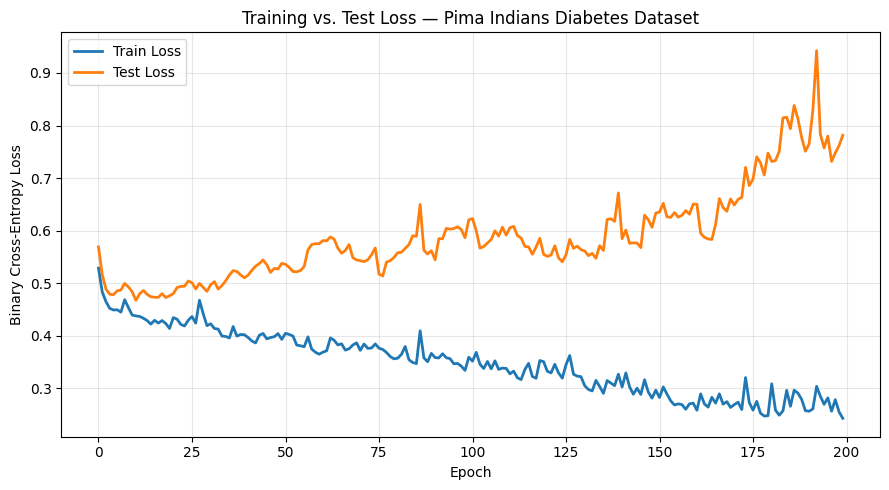

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Test Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training vs. Test Loss — Pima Indians Diabetes Dataset')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

## 11. Bonus: Multi-class Classification Sanity Check (Softmax + Categorical Cross-Entropy)

To confirm the library generalizes beyond binary classification, here's a quick multi-class run on the classic Iris dataset (from `sklearn`, bundled with the library — no download needed), using a `softmax` output layer and `categorical_crossentropy` loss.

Iris (multi-class) test accuracy: 0.9333


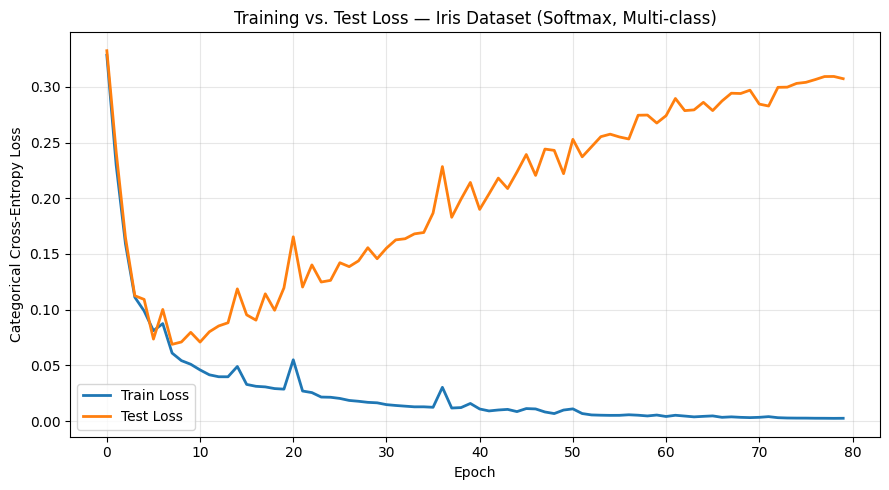

In [12]:
from sklearn.datasets import load_iris

iris = load_iris()
Xi, yi = iris.data, iris.target
Yi = np.eye(3)[yi]  # one-hot encode

idx = np.random.permutation(len(Xi))
split_i = int(0.8 * len(Xi))
Xi_train, Xi_test = Xi[idx[:split_i]], Xi[idx[split_i:]]
Yi_train, Yi_test = Yi[idx[:split_i]], Yi[idx[split_i:]]

mu_i, sd_i = Xi_train.mean(0), Xi_train.std(0)
Xi_train = (Xi_train - mu_i) / sd_i
Xi_test  = (Xi_test  - mu_i) / sd_i

nn_iris = NeuralNetwork(input_dim=4)
nn_iris.add(10, activation='tanh')
nn_iris.add(3, activation='softmax')
nn_iris.compile(loss='categorical_crossentropy', optimizer='adam', learning_rate=0.05)

hist_iris = nn_iris.fit(Xi_train, Yi_train, Xi_test, Yi_test,
                         epochs=80, batch_size=16, verbose=False)

pred_iris = nn_iris.predict(Xi_test)
acc_iris = np.mean(np.argmax(pred_iris, axis=1) == np.argmax(Yi_test, axis=1))
print(f"Iris (multi-class) test accuracy: {acc_iris:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(hist_iris['train_loss'], label='Train Loss', linewidth=2)
plt.plot(hist_iris['val_loss'], label='Test Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.title('Training vs. Test Loss — Iris Dataset (Softmax, Multi-class)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

- Built a fully modular multi-layer neural network using only Python and NumPy
- Supports arbitrary depth/width, 6 activation functions, 4 loss functions, and 2 optimizers (SGD, Adam)
- Validated on the real-world **Pima Indians Diabetes** Kaggle dataset (binary classification) and the **Iris** dataset (multi-class classification)
- Plotted train vs. test loss curves to visualize learning and overfitting behavior

Things you can try next: add dropout / L2 regularization, add a learning-rate scheduler, or add batch normalization as another layer type.